# DhakaNest Rent Prediction — CatBoost

This notebook trains, tunes, validates, analyzes, and exports the CatBoost
rent-prediction candidate using the frozen DhakaNest training and validation
datasets.

The official test dataset remains untouched until the final algorithm has
been selected.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
%pip install -q --upgrade catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [3]:
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter

import hashlib
import json
import os
import platform
import random
import shutil
import warnings

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from catboost import CatBoostRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
)

warnings.filterwarnings("ignore")

print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("CatBoost:", catboost.__version__)

Python: 3.12.13
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
CatBoost: 1.2.10


In [4]:
RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Random state:", RANDOM_STATE)

Random state: 42


In [5]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/DhakaNest_ML"
)

DATA_DIR = PROJECT_ROOT / "data"
SPLITS_DIR = DATA_DIR / "splits"

REPORTS_DIR = PROJECT_ROOT / "reports"
METRICS_DIR = REPORTS_DIR / "metrics"
SEGMENT_DIR = REPORTS_DIR / "segment_evaluation"

CATBOOST_FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
    / "catboost"
)

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

CATBOOST_ARTIFACT_DIR = (
    ARTIFACTS_DIR
    / "candidates"
    / "catboost"
)

MANIFESTS_DIR = PROJECT_ROOT / "manifests"
LOGS_DIR = PROJECT_ROOT / "logs"

TRAIN_PATH = SPLITS_DIR / "train.csv"

VALIDATION_PATH = (
    SPLITS_DIR / "validation.csv"
)

TEST_PATH = SPLITS_DIR / "test.csv"

UNSEEN_TRAIN_PATH = (
    SPLITS_DIR
    / "unseen_micro_area_train.csv"
)

UNSEEN_CHALLENGE_PATH = (
    SPLITS_DIR
    / "unseen_micro_area_challenge.csv"
)

for directory in [
    METRICS_DIR,
    SEGMENT_DIR,
    CATBOOST_FIGURES_DIR,
    CATBOOST_ARTIFACT_DIR,
    MANIFESTS_DIR,
    LOGS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Project root:", PROJECT_ROOT)

print(
    "CatBoost artifact directory:",
    CATBOOST_ARTIFACT_DIR,
)

Project root: /content/drive/MyDrive/DhakaNest_ML
CatBoost artifact directory: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/catboost


In [6]:
required_files = [
    TRAIN_PATH,
    VALIDATION_PATH,
    TEST_PATH,
    UNSEEN_TRAIN_PATH,
    UNSEEN_CHALLENGE_PATH,
]

missing_files = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(missing_files)
    )

print("All required dataset files exist.")
print("The test file exists but will not be loaded.")

All required dataset files exist.
The test file exists but will not be loaded.


In [7]:
LOCAL_WORK_DIR = Path(
    "/content/dhakanest_catboost"
)

LOCAL_DATA_DIR = (
    LOCAL_WORK_DIR / "data"
)

LOCAL_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

local_train_path = (
    LOCAL_DATA_DIR / "train.csv"
)

local_validation_path = (
    LOCAL_DATA_DIR / "validation.csv"
)

local_unseen_train_path = (
    LOCAL_DATA_DIR
    / "unseen_micro_area_train.csv"
)

local_unseen_challenge_path = (
    LOCAL_DATA_DIR
    / "unseen_micro_area_challenge.csv"
)

shutil.copy2(
    TRAIN_PATH,
    local_train_path,
)

shutil.copy2(
    VALIDATION_PATH,
    local_validation_path,
)

shutil.copy2(
    UNSEEN_TRAIN_PATH,
    local_unseen_train_path,
)

shutil.copy2(
    UNSEEN_CHALLENGE_PATH,
    local_unseen_challenge_path,
)

print(
    "Working files copied to:",
    LOCAL_DATA_DIR,
)

Working files copied to: /content/dhakanest_catboost/data


In [8]:
train_df = pd.read_csv(
    local_train_path
)

validation_df = pd.read_csv(
    local_validation_path
)

unseen_train_df = pd.read_csv(
    local_unseen_train_path
)

unseen_challenge_df = pd.read_csv(
    local_unseen_challenge_path
)

print("Training shape:", train_df.shape)

print(
    "Validation shape:",
    validation_df.shape,
)

print(
    "Unseen training shape:",
    unseen_train_df.shape,
)

print(
    "Unseen challenge shape:",
    unseen_challenge_df.shape,
)

Training shape: (10668, 11)
Validation shape: (2289, 11)
Unseen training shape: (9549, 11)
Unseen challenge shape: (1119, 11)


In [9]:
CATEGORICAL_FEATURES = [
    "broad_area",
    "model_micro_area",
]

NUMERICAL_FEATURES = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
]

FEATURE_COLUMNS = (
    CATEGORICAL_FEATURES
    + NUMERICAL_FEATURES
)

TARGET_COLUMN = "base_rent_bdt"

GROUP_COLUMN = "duplicate_group_id"

CATEGORICAL_INDICES = [
    FEATURE_COLUMNS.index(column)
    for column in CATEGORICAL_FEATURES
]

print("Feature order:", FEATURE_COLUMNS)

print(
    "Categorical indices:",
    CATEGORICAL_INDICES,
)

print("Target:", TARGET_COLUMN)

Feature order: ['broad_area', 'model_micro_area', 'area_sqft', 'bedrooms', 'bathrooms']
Categorical indices: [0, 1]
Target: base_rent_bdt


In [10]:
REQUIRED_COLUMNS = [
    *FEATURE_COLUMNS,
    TARGET_COLUMN,
    GROUP_COLUMN,
    "record_id",
    "location_raw",
    "micro_area",
    "micro_area_support_count",
]

for dataset_name, dataframe in [
    ("train", train_df),
    ("validation", validation_df),
    ("unseen_train", unseen_train_df),
    (
        "unseen_challenge",
        unseen_challenge_df,
    ),
]:
    missing_columns = [
        column
        for column in REQUIRED_COLUMNS
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing columns: "
            f"{missing_columns}"
        )

    if dataframe[
        FEATURE_COLUMNS + [TARGET_COLUMN]
    ].isna().any().any():
        raise ValueError(
            f"{dataset_name} contains missing "
            "model values."
        )

    for numeric_column in [
        *NUMERICAL_FEATURES,
        TARGET_COLUMN,
    ]:
        if (
            dataframe[numeric_column] <= 0
        ).any():
            raise ValueError(
                f"{dataset_name} contains "
                f"non-positive {numeric_column}."
            )

print(
    "Dataset schema and value validation passed."
)

Dataset schema and value validation passed.


In [11]:
train_record_ids = set(
    train_df["record_id"]
)

validation_record_ids = set(
    validation_df["record_id"]
)

train_groups = set(
    train_df[GROUP_COLUMN]
)

validation_groups = set(
    validation_df[GROUP_COLUMN]
)

assert train_record_ids.isdisjoint(
    validation_record_ids
), "Record leakage detected."

assert train_groups.isdisjoint(
    validation_groups
), "Duplicate-group leakage detected."

print(
    "Training and validation isolation passed."
)

Training and validation isolation passed.


In [12]:
def prepare_catboost_features(
    dataframe,
    feature_columns,
    categorical_features,
):
    prepared = dataframe[
        feature_columns
    ].copy()

    for column in categorical_features:
        prepared[column] = (
            prepared[column]
            .astype("string")
            .fillna("Unknown")
            .astype(str)
        )

    numerical_features = [
        column
        for column in feature_columns
        if column not in categorical_features
    ]

    for column in numerical_features:
        prepared[column] = pd.to_numeric(
            prepared[column],
            errors="raise",
        ).astype(float)

    return prepared

In [13]:
X_train = prepare_catboost_features(
    train_df,
    FEATURE_COLUMNS,
    CATEGORICAL_FEATURES,
)

y_train = train_df[
    TARGET_COLUMN
].astype(float)

X_validation = prepare_catboost_features(
    validation_df,
    FEATURE_COLUMNS,
    CATEGORICAL_FEATURES,
)

y_validation = validation_df[
    TARGET_COLUMN
].astype(float)

training_groups = train_df[
    GROUP_COLUMN
].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print(
    "X_validation:",
    X_validation.shape,
)

print(
    "y_validation:",
    y_validation.shape,
)

print(
    "Training duplicate groups:",
    training_groups.nunique(),
)

print("\nTraining dtypes:")
display(X_train.dtypes)

X_train: (10668, 5)
y_train: (10668,)
X_validation: (2289, 5)
y_validation: (2289,)
Training duplicate groups: 9723

Training dtypes:


,0
broad_area,object
model_micro_area,object
area_sqft,float64
bedrooms,float64
bathrooms,float64


In [14]:
environment_info = {
    "python_version": (
        platform.python_version()
    ),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "scikit_learn_version": (
        sklearn.__version__
    ),
    "catboost_version": (
        catboost.__version__
    ),
    "random_state": RANDOM_STATE,
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
}

ENVIRONMENT_PATH = (
    CATBOOST_ARTIFACT_DIR
    / "training_environment.json"
)

with ENVIRONMENT_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        environment_info,
        file,
        indent=2,
    )

print(
    json.dumps(
        environment_info,
        indent=2,
    )
)

print("Saved:", ENVIRONMENT_PATH)

{
  "python_version": "3.12.13",
  "pandas_version": "2.2.2",
  "numpy_version": "2.0.2",
  "scikit_learn_version": "1.6.1",
  "catboost_version": "1.2.10",
  "random_state": 42,
  "created_at_utc": "2026-07-31T05:48:06.376540+00:00"
}
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/catboost/training_environment.json


In [15]:
def calculate_regression_metrics(
    y_true,
    y_pred,
):
    y_true_array = np.asarray(
        y_true,
        dtype=float,
    )

    y_pred_array = np.asarray(
        y_pred,
        dtype=float,
    )

    absolute_errors = np.abs(
        y_true_array - y_pred_array
    )

    return {
        "mae_bdt": float(
            mean_absolute_error(
                y_true_array,
                y_pred_array,
            )
        ),
        "rmse_bdt": float(
            np.sqrt(
                mean_squared_error(
                    y_true_array,
                    y_pred_array,
                )
            )
        ),
        "r2": float(
            r2_score(
                y_true_array,
                y_pred_array,
            )
        ),
        "mape_percent": float(
            mean_absolute_percentage_error(
                y_true_array,
                y_pred_array,
            )
            * 100
        ),
        "median_absolute_error_bdt": float(
            median_absolute_error(
                y_true_array,
                y_pred_array,
            )
        ),
        "p90_absolute_error_bdt": float(
            np.percentile(
                absolute_errors,
                90,
            )
        ),
    }

In [16]:
def convert_predictions_to_bdt(
    predictions,
    target_strategy,
):
    predictions = np.asarray(
        predictions,
        dtype=float,
    )

    if target_strategy == "log1p":
        predictions = np.expm1(
            predictions
        )

    return np.maximum(
        predictions,
        0,
    )


def evaluate_catboost_model(
    model,
    X,
    y_true,
    target_strategy,
):
    prediction_start = perf_counter()

    raw_predictions = model.predict(X)

    prediction_seconds = (
        perf_counter()
        - prediction_start
    )

    predictions_bdt = (
        convert_predictions_to_bdt(
            raw_predictions,
            target_strategy,
        )
    )

    metrics = calculate_regression_metrics(
        y_true,
        predictions_bdt,
    )

    metrics[
        "prediction_time_seconds"
    ] = float(prediction_seconds)

    metrics[
        "milliseconds_per_record"
    ] = float(
        prediction_seconds
        / max(len(y_true), 1)
        * 1000
    )

    return metrics, predictions_bdt

In [17]:
def flatten_model_result(
    model_name,
    train_metrics,
    validation_metrics,
    training_time_seconds,
):
    return {
        "model_name": model_name,
        "training_time_seconds": float(
            training_time_seconds
        ),
        "train_mae_bdt": (
            train_metrics["mae_bdt"]
        ),
        "validation_mae_bdt": (
            validation_metrics["mae_bdt"]
        ),
        "validation_rmse_bdt": (
            validation_metrics["rmse_bdt"]
        ),
        "validation_r2": (
            validation_metrics["r2"]
        ),
        "validation_mape_percent": (
            validation_metrics[
                "mape_percent"
            ]
        ),
        "validation_median_absolute_error_bdt": (
            validation_metrics[
                "median_absolute_error_bdt"
            ]
        ),
        "validation_p90_absolute_error_bdt": (
            validation_metrics[
                "p90_absolute_error_bdt"
            ]
        ),
        "train_validation_mae_gap_bdt": float(
            validation_metrics["mae_bdt"]
            - train_metrics["mae_bdt"]
        ),
        "validation_prediction_time_seconds": (
            validation_metrics[
                "prediction_time_seconds"
            ]
        ),
    }

## Dummy Median Baseline

The baseline predicts the median training rent for every property. CatBoost
must clearly outperform this baseline.

In [18]:
dummy_model = DummyRegressor(
    strategy="median"
)

dummy_X_train = np.zeros(
    shape=(len(y_train), 1)
)

dummy_X_validation = np.zeros(
    shape=(len(y_validation), 1)
)

dummy_training_start = perf_counter()

dummy_model.fit(
    dummy_X_train,
    y_train,
)

dummy_training_time = (
    perf_counter()
    - dummy_training_start
)

dummy_train_prediction_start = (
    perf_counter()
)

dummy_train_predictions = (
    dummy_model.predict(
        dummy_X_train
    )
)

dummy_train_prediction_time = (
    perf_counter()
    - dummy_train_prediction_start
)

dummy_validation_prediction_start = (
    perf_counter()
)

dummy_validation_predictions = (
    dummy_model.predict(
        dummy_X_validation
    )
)

dummy_validation_prediction_time = (
    perf_counter()
    - dummy_validation_prediction_start
)

dummy_train_metrics = (
    calculate_regression_metrics(
        y_train,
        dummy_train_predictions,
    )
)

dummy_validation_metrics = (
    calculate_regression_metrics(
        y_validation,
        dummy_validation_predictions,
    )
)

dummy_train_metrics[
    "prediction_time_seconds"
] = float(
    dummy_train_prediction_time
)

dummy_validation_metrics[
    "prediction_time_seconds"
] = float(
    dummy_validation_prediction_time
)

print("Dummy training metrics:")
display(
    pd.DataFrame(
        [dummy_train_metrics]
    )
)

print("Dummy validation metrics:")
display(
    pd.DataFrame(
        [dummy_validation_metrics]
    )
)

Dummy training metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds
0,9785.46213,25280.329656,-0.062665,32.313069,5000.0,18000.0,0.000354


Dummy validation metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds
0,9648.186981,23000.801441,-0.072099,32.733671,5000.0,18200.0,0.000328


## Initial CatBoost Model

An initial CatBoost regressor is trained before hyperparameter tuning to
establish a reference result.

In [19]:
initial_catboost_model = (
    CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="MAE",
        iterations=800,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3.0,
        random_strength=1.0,
        bootstrap_type="Bayesian",
        bagging_temperature=1.0,
        random_seed=RANDOM_STATE,
        thread_count=-1,
        verbose=False,
        allow_writing_files=False,
        cat_features=(
            CATEGORICAL_INDICES
        ),
    )
)

print(initial_catboost_model)

CatBoostRegressor(allow_writing_files=False, bagging_temperature=1.0, bootstrap_type='Bayesian', cat_features=[0, 1], depth=6, eval_metric='MAE', iterations=800, l2_leaf_reg=3.0, learning_rate=0.05, loss_function='RMSE', random_seed=42, random_strength=1.0, verbose=False)


In [20]:
initial_training_start = (
    perf_counter()
)

initial_catboost_model.fit(
    X_train,
    y_train,
    verbose=False,
)

initial_training_time = (
    perf_counter()
    - initial_training_start
)

initial_train_metrics, (
    initial_train_predictions
) = evaluate_catboost_model(
    initial_catboost_model,
    X_train,
    y_train,
    target_strategy="raw",
)

initial_validation_metrics, (
    initial_validation_predictions
) = evaluate_catboost_model(
    initial_catboost_model,
    X_validation,
    y_validation,
    target_strategy="raw",
)

print("Initial CatBoost training metrics:")

display(
    pd.DataFrame(
        [initial_train_metrics]
    )
)

print(
    "Initial CatBoost validation metrics:"
)

display(
    pd.DataFrame(
        [initial_validation_metrics]
    )
)

Initial CatBoost training metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3383.695107,7461.907827,0.907417,13.653245,1850.247362,6766.449105,0.040071,0.003756


Initial CatBoost validation metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3995.614493,9736.106671,0.807903,14.571116,1896.627984,7839.533784,0.009202,0.00402


## CatBoost Hyperparameter Tuning

RandomizedSearchCV uses five-fold GroupKFold cross-validation. Only the frozen
training dataset is used during hyperparameter search.

In [27]:
for variable_name in [
    "search",
    "tuning_model",
]:
    if variable_name in globals():
        del globals()[variable_name]

print("Old CatBoost search objects removed.")

Old CatBoost search objects removed.


In [28]:
from sklearn.base import clone

tuning_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="MAE",
    bootstrap_type="Bayesian",
    random_seed=RANDOM_STATE,
    thread_count=1,
    verbose=False,
    allow_writing_files=False,
)

print(
    "Constructor cat_features:",
    tuning_model.get_params().get(
        "cat_features"
    ),
)

# Confirm that scikit-learn can clone it.
clone_test_model = clone(tuning_model)

print("CatBoost estimator clone test passed.")

Constructor cat_features: None
CatBoost estimator clone test passed.


In [29]:
parameter_distributions = {
    "iterations": [
        400,
        700,
        1000,
        1300,
    ],
    "learning_rate": [
        0.02,
        0.04,
        0.06,
        0.10,
    ],
    "depth": [
        4,
        6,
        8,
        10,
    ],
    "l2_leaf_reg": [
        1.0,
        3.0,
        5.0,
        10.0,
    ],
    "random_strength": [
        0.5,
        1.0,
        2.0,
        5.0,
    ],
    "bagging_temperature": [
        0.0,
        0.5,
        1.0,
        2.0,
    ],
    "border_count": [
        64,
        128,
        254,
    ],
}

print(
    "CatBoost search space configured."
)

CatBoost search space configured.


In [30]:
group_cv = GroupKFold(
    n_splits=5
)

search = RandomizedSearchCV(
    estimator=tuning_model,
    param_distributions=(
        parameter_distributions
    ),
    n_iter=15,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    cv=group_cv,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True,
    error_score="raise",
    pre_dispatch="2*n_jobs",
)

print("Search candidates:", search.n_iter)
print("Cross-validation folds:", 5)
print(
    "Total model fits:",
    search.n_iter * 5,
)

print(
    "cat_features stored in search estimator:",
    search.estimator.get_params().get(
        "cat_features"
    ),
)

Search candidates: 15
Cross-validation folds: 5
Total model fits: 75
cat_features stored in search estimator: None


In [31]:
tuning_start = perf_counter()

search.fit(
    X_train,
    y_train,
    groups=training_groups,
    cat_features=CATEGORICAL_INDICES,
)

tuning_time_seconds = (
    perf_counter()
    - tuning_start
)

print("CatBoost tuning completed.")

print(
    "Tuning time in seconds:",
    round(
        tuning_time_seconds,
        2,
    ),
)

print(
    "Best cross-validation MAE:",
    round(
        -search.best_score_,
        2,
    ),
)

print("Best parameters:")

display(
    pd.DataFrame(
        list(
            search.best_params_.items()
        ),
        columns=[
            "parameter",
            "value",
        ],
    )
)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
CatBoost tuning completed.
Tuning time in seconds: 445.0
Best cross-validation MAE: 3728.13
Best parameters:


,parameter,value
0,random_strength,2.00
1,learning_rate,0.06
2,l2_leaf_reg,1.00
3,iterations,1300.00
4,depth,6.00
5,border_count,254.00
6,bagging_temperature,0.50


In [32]:
cv_results_df = pd.DataFrame(
    search.cv_results_
)

cv_results_df[
    "mean_test_mae_bdt"
] = -cv_results_df[
    "mean_test_score"
]

cv_results_df[
    "mean_train_mae_bdt"
] = -cv_results_df[
    "mean_train_score"
]

cv_results_df = (
    cv_results_df.sort_values(
        "mean_test_mae_bdt",
        ascending=True,
    )
)

CV_RESULTS_PATH = (
    METRICS_DIR
    / "catboost_cv_results.csv"
)

cv_results_df.to_csv(
    CV_RESULTS_PATH,
    index=False,
)

display(
    cv_results_df[
        [
            "rank_test_score",
            "mean_test_mae_bdt",
            "std_test_score",
            "mean_train_mae_bdt",
            "mean_fit_time",
            "params",
        ]
    ].head(15)
)

print("Saved:", CV_RESULTS_PATH)

,rank_test_score,mean_test_mae_bdt,std_test_score,mean_train_mae_bdt,mean_fit_time,params
10,1,3728.134234,136.379112,3042.275675,17.645132,"{'random_strength': 2.0, 'learning_rate': 0.06..."
6,2,3728.895605,131.247428,3340.034344,13.406950,"{'random_strength': 2.0, 'learning_rate': 0.04..."
2,3,3738.765953,125.095252,3226.594559,5.912186,"{'random_strength': 2.0, 'learning_rate': 0.1,..."
8,4,3743.134436,76.626597,3497.173519,13.385174,"{'random_strength': 2.0, 'learning_rate': 0.02..."
9,5,3775.593008,81.037726,3311.760542,8.539326,"{'random_strength': 2.0, 'learning_rate': 0.06..."
1,6,3783.893804,83.602709,3106.846894,22.765457,"{'random_strength': 0.5, 'learning_rate': 0.1,..."
3,7,3794.925392,134.728154,3500.724452,5.686968,"{'random_strength': 5.0, 'learning_rate': 0.04..."
13,8,3821.504096,84.452174,3354.928030,23.314247,"{'random_strength': 5.0, 'learning_rate': 0.04..."
14,9,3844.018025,108.790616,3621.102859,8.327341,"{'random_strength': 2.0, 'learning_rate': 0.02..."
4,10,3848.076585,109.665364,3187.959379,20.401484,"{'random_strength': 0.5, 'learning_rate': 0.1,..."


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/catboost_cv_results.csv


In [33]:
best_search_parameters = (
    search.best_params_.copy()
)

searched_iterations = int(
    best_search_parameters.pop(
        "iterations"
    )
)

print(
    "Best searched iterations:",
    searched_iterations,
)

print("Best core parameters:")

display(
    pd.DataFrame(
        list(
            best_search_parameters.items()
        ),
        columns=[
            "parameter",
            "value",
        ],
    )
)

Best searched iterations: 1300
Best core parameters:


,parameter,value
0,random_strength,2.00
1,learning_rate,0.06
2,l2_leaf_reg,1.00
3,depth,6.00
4,border_count,254.00
5,bagging_temperature,0.50


In [34]:
MAX_FINAL_ITERATIONS = 3000

EARLY_STOPPING_ROUNDS = 75


def create_final_catboost_model(
    categorical_indices,
):
    return CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="MAE",
        iterations=(
            MAX_FINAL_ITERATIONS
        ),
        bootstrap_type="Bayesian",
        random_seed=RANDOM_STATE,
        thread_count=-1,
        verbose=False,
        allow_writing_files=False,
        cat_features=(
            categorical_indices
        ),
        **best_search_parameters,
    )


print(
    "Maximum final iterations:",
    MAX_FINAL_ITERATIONS,
)

print(
    "Early stopping rounds:",
    EARLY_STOPPING_ROUNDS,
)

Maximum final iterations: 3000
Early stopping rounds: 75


## Final Raw-Target CatBoost

The tuned CatBoost configuration is trained on the original BDT rent target
with validation-based early stopping.

In [35]:
raw_catboost_model = (
    create_final_catboost_model(
        CATEGORICAL_INDICES
    )
)

raw_training_start = perf_counter()

raw_catboost_model.fit(
    X_train,
    y_train,
    eval_set=(
        X_validation,
        y_validation,
    ),
    use_best_model=True,
    early_stopping_rounds=(
        EARLY_STOPPING_ROUNDS
    ),
    verbose=False,
)

raw_training_time = (
    perf_counter()
    - raw_training_start
)

raw_train_metrics, (
    raw_train_predictions
) = evaluate_catboost_model(
    raw_catboost_model,
    X_train,
    y_train,
    target_strategy="raw",
)

raw_validation_metrics, (
    raw_validation_predictions
) = evaluate_catboost_model(
    raw_catboost_model,
    X_validation,
    y_validation,
    target_strategy="raw",
)

print(
    "Raw-target best iteration:",
    raw_catboost_model.get_best_iteration(),
)

print(
    "Raw-target saved tree count:",
    raw_catboost_model.tree_count_,
)

print("\nRaw-target training metrics:")

display(
    pd.DataFrame(
        [raw_train_metrics]
    )
)

print(
    "\nRaw-target validation metrics:"
)

display(
    pd.DataFrame(
        [raw_validation_metrics]
    )
)

Raw-target best iteration: 262
Raw-target saved tree count: 263

Raw-target training metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3477.414721,8024.003947,0.892943,13.705377,1875.937204,6872.525449,0.021773,0.002041



Raw-target validation metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3931.396457,9417.902063,0.820255,14.431743,1856.246536,7481.270969,0.00564,0.002464


## Final Log-Target CatBoost

The tuned CatBoost configuration is trained on `log1p(base_rent_bdt)`.
Predictions are converted back to BDT before evaluation.

In [36]:
y_train_log = np.log1p(
    y_train.to_numpy()
)

y_validation_log = np.log1p(
    y_validation.to_numpy()
)

log_catboost_model = (
    create_final_catboost_model(
        CATEGORICAL_INDICES
    )
)

log_training_start = perf_counter()

log_catboost_model.fit(
    X_train,
    y_train_log,
    eval_set=(
        X_validation,
        y_validation_log,
    ),
    use_best_model=True,
    early_stopping_rounds=(
        EARLY_STOPPING_ROUNDS
    ),
    verbose=False,
)

log_training_time = (
    perf_counter()
    - log_training_start
)

log_train_metrics, (
    log_train_predictions
) = evaluate_catboost_model(
    log_catboost_model,
    X_train,
    y_train,
    target_strategy="log1p",
)

log_validation_metrics, (
    log_validation_predictions
) = evaluate_catboost_model(
    log_catboost_model,
    X_validation,
    y_validation,
    target_strategy="log1p",
)

print(
    "Log-target best iteration:",
    log_catboost_model.get_best_iteration(),
)

print(
    "Log-target saved tree count:",
    log_catboost_model.tree_count_,
)

print(
    "\nLog-target training metrics in BDT:"
)

display(
    pd.DataFrame(
        [log_train_metrics]
    )
)

print(
    "\nLog-target validation metrics in BDT:"
)

display(
    pd.DataFrame(
        [log_validation_metrics]
    )
)

Log-target best iteration: 807
Log-target saved tree count: 808

Log-target training metrics in BDT:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3055.890979,7655.607491,0.902548,11.646886,1591.715332,5802.306645,0.041687,0.003908



Log-target validation metrics in BDT:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record
0,3635.502536,9238.220267,0.827048,12.725463,1621.405849,6519.84821,0.010209,0.00446


In [37]:
def plot_catboost_learning_curve(
    model,
    title,
    y_axis_label,
    output_path,
):
    evaluation_results = (
        model.get_evals_result()
    )

    learning_key = "learn"

    validation_keys = [
        key
        for key in evaluation_results
        if key != learning_key
    ]

    if not validation_keys:
        raise ValueError(
            "Validation history not found."
        )

    validation_key = (
        validation_keys[-1]
    )

    learning_metrics = (
        evaluation_results[
            learning_key
        ]
    )

    metric_name = (
        "MAE"
        if "MAE" in learning_metrics
        else next(
            iter(
                learning_metrics.keys()
            )
        )
    )

    training_history = (
        evaluation_results[
            learning_key
        ][metric_name]
    )

    validation_history = (
        evaluation_results[
            validation_key
        ][metric_name]
    )

    plt.figure(figsize=(9, 5))

    plt.plot(
        training_history,
        label="Training",
    )

    plt.plot(
        validation_history,
        label="Validation",
    )

    best_iteration = (
        model.get_best_iteration()
    )

    if best_iteration is not None:
        plt.axvline(
            best_iteration,
            linestyle="--",
            label="Best iteration",
        )

    plt.xlabel("Boosting iteration")
    plt.ylabel(y_axis_label)
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", output_path)

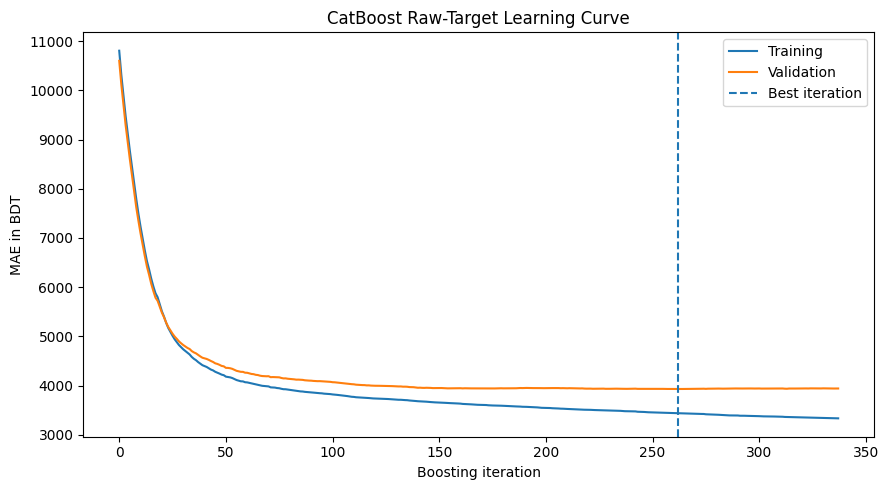

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/catboost/raw_target_learning_curve.png


In [38]:
RAW_LEARNING_CURVE_PATH = (
    CATBOOST_FIGURES_DIR
    / "raw_target_learning_curve.png"
)

plot_catboost_learning_curve(
    raw_catboost_model,
    title=(
        "CatBoost Raw-Target "
        "Learning Curve"
    ),
    y_axis_label="MAE in BDT",
    output_path=(
        RAW_LEARNING_CURVE_PATH
    ),
)

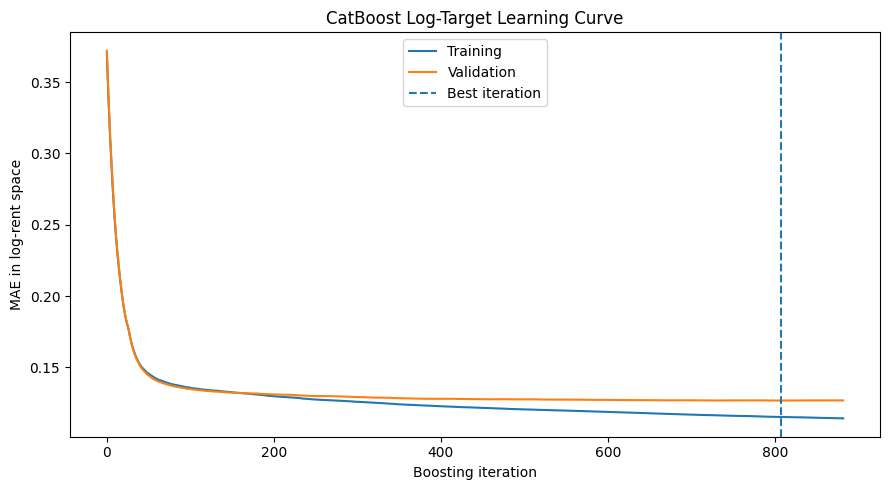

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/catboost/log_target_learning_curve.png


In [39]:
LOG_LEARNING_CURVE_PATH = (
    CATBOOST_FIGURES_DIR
    / "log_target_learning_curve.png"
)

plot_catboost_learning_curve(
    log_catboost_model,
    title=(
        "CatBoost Log-Target "
        "Learning Curve"
    ),
    y_axis_label=(
        "MAE in log-rent space"
    ),
    output_path=(
        LOG_LEARNING_CURVE_PATH
    ),
)

In [40]:
comparison_rows = [
    flatten_model_result(
        "Dummy Median Baseline",
        dummy_train_metrics,
        dummy_validation_metrics,
        dummy_training_time,
    ),
    flatten_model_result(
        "Initial CatBoost",
        initial_train_metrics,
        initial_validation_metrics,
        initial_training_time,
    ),
    flatten_model_result(
        "Tuned CatBoost — Raw Target",
        raw_train_metrics,
        raw_validation_metrics,
        raw_training_time,
    ),
    flatten_model_result(
        "Tuned CatBoost — Log Target",
        log_train_metrics,
        log_validation_metrics,
        log_training_time,
    ),
]

catboost_comparison_df = (
    pd.DataFrame(
        comparison_rows
    )
    .sort_values(
        "validation_mae_bdt",
        ascending=True,
    )
)

CATBOOST_COMPARISON_PATH = (
    METRICS_DIR
    / "catboost_validation_comparison.csv"
)

catboost_comparison_df.to_csv(
    CATBOOST_COMPARISON_PATH,
    index=False,
)

display(catboost_comparison_df)

print(
    "Saved:",
    CATBOOST_COMPARISON_PATH,
)

,model_name,training_time_seconds,train_mae_bdt,validation_mae_bdt,validation_rmse_bdt,validation_r2,validation_mape_percent,validation_median_absolute_error_bdt,validation_p90_absolute_error_bdt,train_validation_mae_gap_bdt,validation_prediction_time_seconds
3,Tuned CatBoost — Log Target,9.835557,3055.890979,3635.502536,9238.220267,0.827048,12.725463,1621.405849,6519.848210,579.611558,0.010209
2,Tuned CatBoost — Raw Target,3.230941,3477.414721,3931.396457,9417.902063,0.820255,14.431743,1856.246536,7481.270969,453.981736,0.005640
1,Initial CatBoost,6.179003,3383.695107,3995.614493,9736.106671,0.807903,14.571116,1896.627984,7839.533784,611.919386,0.009202
0,Dummy Median Baseline,0.001849,9785.462130,9648.186981,23000.801441,-0.072099,32.733671,5000.000000,18200.000000,-137.275149,0.000328


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/catboost_validation_comparison.csv


In [41]:
if (
    log_validation_metrics[
        "mae_bdt"
    ]
    < raw_validation_metrics[
        "mae_bdt"
    ]
):
    chosen_model = (
        log_catboost_model
    )

    chosen_target_strategy = (
        "log1p"
    )

    chosen_train_metrics = (
        log_train_metrics
    )

    chosen_validation_metrics = (
        log_validation_metrics
    )

    chosen_train_predictions = (
        log_train_predictions
    )

    chosen_validation_predictions = (
        log_validation_predictions
    )

    chosen_training_time = (
        log_training_time
    )
else:
    chosen_model = (
        raw_catboost_model
    )

    chosen_target_strategy = "raw"

    chosen_train_metrics = (
        raw_train_metrics
    )

    chosen_validation_metrics = (
        raw_validation_metrics
    )

    chosen_train_predictions = (
        raw_train_predictions
    )

    chosen_validation_predictions = (
        raw_validation_predictions
    )

    chosen_training_time = (
        raw_training_time
    )

print(
    "Selected CatBoost target strategy:",
    chosen_target_strategy,
)

print(
    "Selected validation MAE:",
    round(
        chosen_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
)

print(
    "Selected best iteration:",
    chosen_model.get_best_iteration(),
)

print(
    "Selected tree count:",
    chosen_model.tree_count_,
)

Selected CatBoost target strategy: log1p
Selected validation MAE: 3635.5
Selected best iteration: 807
Selected tree count: 808


In [42]:
validation_results_df = (
    validation_df[
        [
            "record_id",
            "location_raw",
            "broad_area",
            "micro_area",
            "model_micro_area",
            "micro_area_support_count",
            "area_sqft",
            "bedrooms",
            "bathrooms",
            "base_rent_bdt",
        ]
    ].copy()
)

validation_results_df[
    "predicted_rent_bdt"
] = chosen_validation_predictions

validation_results_df[
    "residual_bdt"
] = (
    validation_results_df[
        "base_rent_bdt"
    ]
    - validation_results_df[
        "predicted_rent_bdt"
    ]
)

validation_results_df[
    "absolute_error_bdt"
] = validation_results_df[
    "residual_bdt"
].abs()

validation_results_df[
    "absolute_percentage_error"
] = (
    validation_results_df[
        "absolute_error_bdt"
    ]
    / validation_results_df[
        "base_rent_bdt"
    ]
    * 100
)

VALIDATION_PREDICTIONS_PATH = (
    METRICS_DIR
    / "catboost_validation_predictions.csv"
)

validation_results_df.to_csv(
    VALIDATION_PREDICTIONS_PATH,
    index=False,
)

display(
    validation_results_df.head(20)
)

print(
    "Saved:",
    VALIDATION_PREDICTIONS_PATH,
)

,record_id,location_raw,broad_area,micro_area,model_micro_area,micro_area_support_count,area_sqft,bedrooms,bathrooms,base_rent_bdt,predicted_rent_bdt,residual_bdt,absolute_error_bdt,absolute_percentage_error
0,DN-000004,"Gulshan 1, Gulshan, Dhaka",Gulshan,Gulshan 1,Gulshan 1,82,2200,3,4,75000,81035.338235,-6035.338235,6035.338235,8.047118
1,DN-000006,"Bashundhara R-A, Dhaka",Bashundhara R/A,Bashundhara R/A,OTHER_BASHUNDHARA_R_A,17,3000,4,5,50000,65619.251098,-15619.251098,15619.251098,31.238502
2,DN-000018,"Block K, Baridhara, Dhaka",Baridhara,Block K,Block K,34,3000,4,4,160000,164385.273322,-4385.273322,4385.273322,2.740796
3,DN-000030,"Rajabazar, Tejgaon, Dhaka",Tejgaon,Rajabazar,Rajabazar,43,650,2,2,18000,18894.257050,-894.257050,894.257050,4.968095
4,DN-000038,"Block G, Bashundhara R-A, Dhaka",Bashundhara R/A,Block G,Block G,121,1750,3,4,30000,30610.112700,-610.112700,610.112700,2.033709
5,DN-000050,"Block A, Bashundhara R-A, Dhaka",Bashundhara R/A,Block A,Block A,79,1860,3,4,38000,36444.501894,1555.498106,1555.498106,4.093416
6,DN-000055,"Block G, Bashundhara R-A, Dhaka",Bashundhara R/A,Block G,Block G,121,1400,3,3,28000,25369.630706,2630.369294,2630.369294,9.394176
7,DN-000058,"Malibagh, Dhaka",Malibagh,Malibagh,Malibagh,109,1300,3,3,30000,25794.081251,4205.918749,4205.918749,14.019729
8,DN-000060,"West Dhanmondi and Shangkar, Dhanmondi, Dhaka",Dhanmondi,West Dhanmondi And Shangkar,West Dhanmondi And Shangkar,94,1000,3,2,18000,20385.993848,-2385.993848,2385.993848,13.255521
9,DN-000062,"Block F, Bashundhara R-A, Dhaka",Bashundhara R/A,Block F,Block F,99,1800,3,4,30000,31605.600567,-1605.600567,1605.600567,5.352002


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/catboost_validation_predictions.csv


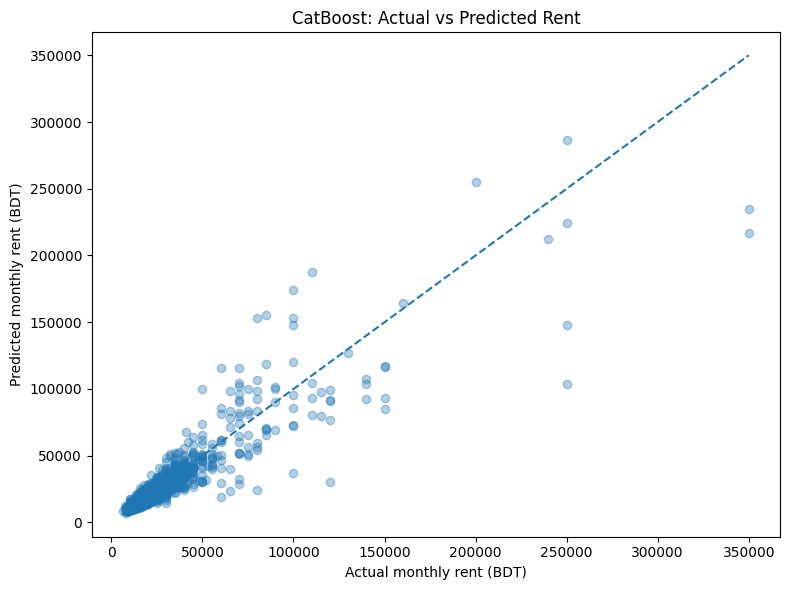

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/catboost/actual_vs_predicted.png


In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(
    validation_results_df[
        "base_rent_bdt"
    ],
    validation_results_df[
        "predicted_rent_bdt"
    ],
    alpha=0.35,
)

minimum_value = min(
    validation_results_df[
        "base_rent_bdt"
    ].min(),
    validation_results_df[
        "predicted_rent_bdt"
    ].min(),
)

maximum_value = max(
    validation_results_df[
        "base_rent_bdt"
    ].max(),
    validation_results_df[
        "predicted_rent_bdt"
    ].max(),
)

plt.plot(
    [
        minimum_value,
        maximum_value,
    ],
    [
        minimum_value,
        maximum_value,
    ],
    linestyle="--",
)

plt.xlabel(
    "Actual monthly rent (BDT)"
)

plt.ylabel(
    "Predicted monthly rent (BDT)"
)

plt.title(
    "CatBoost: Actual vs Predicted Rent"
)

plt.tight_layout()

ACTUAL_PREDICTED_FIGURE_PATH = (
    CATBOOST_FIGURES_DIR
    / "actual_vs_predicted.png"
)

plt.savefig(
    ACTUAL_PREDICTED_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    ACTUAL_PREDICTED_FIGURE_PATH,
)

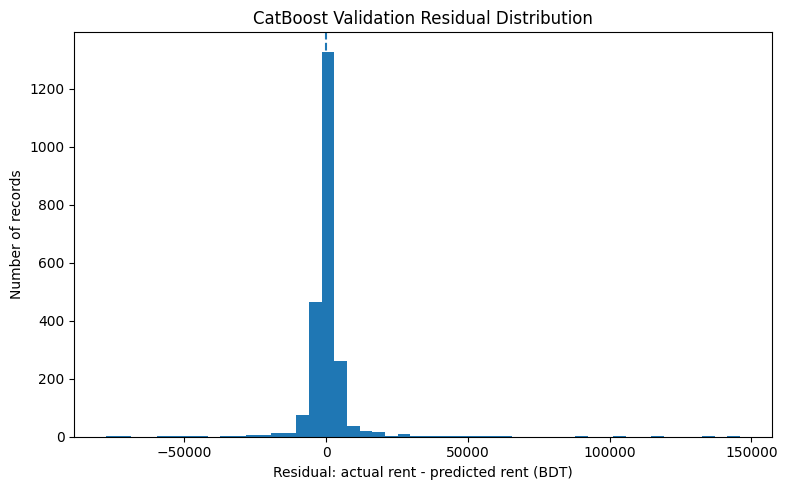

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/catboost/validation_residual_distribution.png


In [44]:
plt.figure(figsize=(8, 5))

plt.hist(
    validation_results_df[
        "residual_bdt"
    ],
    bins=50,
)

plt.axvline(
    0,
    linestyle="--",
)

plt.xlabel(
    "Residual: actual rent - "
    "predicted rent (BDT)"
)

plt.ylabel("Number of records")

plt.title(
    "CatBoost Validation "
    "Residual Distribution"
)

plt.tight_layout()

RESIDUAL_FIGURE_PATH = (
    CATBOOST_FIGURES_DIR
    / "validation_residual_distribution.png"
)

plt.savefig(
    RESIDUAL_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    RESIDUAL_FIGURE_PATH,
)

In [45]:
largest_errors_df = (
    validation_results_df
    .sort_values(
        "absolute_error_bdt",
        ascending=False,
    )
    .head(30)
)

display(
    largest_errors_df[
        [
            "record_id",
            "location_raw",
            "area_sqft",
            "bedrooms",
            "bathrooms",
            "base_rent_bdt",
            "predicted_rent_bdt",
            "absolute_error_bdt",
            "absolute_percentage_error",
        ]
    ]
)

LARGEST_ERRORS_PATH = (
    METRICS_DIR
    / "catboost_largest_validation_errors.csv"
)

largest_errors_df.to_csv(
    LARGEST_ERRORS_PATH,
    index=False,
)

print(
    "Saved:",
    LARGEST_ERRORS_PATH,
)

,record_id,location_raw,area_sqft,bedrooms,bathrooms,base_rent_bdt,predicted_rent_bdt,absolute_error_bdt,absolute_percentage_error
23,DN-000182,"Gulshan 2, Gulshan, Dhaka",2800,4,4,250000,104051.105856,145948.894144,58.379558
222,DN-001737,"Baridhara, Dhaka",3850,3,3,350000,216998.134684,133001.865316,38.000533
1446,DN-016537,"Baridhara, Dhaka",4550,4,4,350000,234769.320637,115230.679363,32.923051
1634,DN-018936,"Gulshan 2, Gulshan, Dhaka",3200,4,4,250000,148295.393454,101704.606546,40.681843
50,DN-000388,"Block A, Bashundhara R-A, Dhaka",1450,3,3,120000,30593.998514,89406.001486,74.505001
89,DN-000672,"Block K, Baridhara, Dhaka",2800,3,3,110000,187591.924839,77591.924839,70.538113
127,DN-001023,"Gulshan 1, Gulshan, Dhaka",3500,4,4,100000,174043.517486,74043.517486,74.043517
162,DN-001227,"Gulshan 2, Gulshan, Dhaka",3187,3,3,80000,152912.581647,72912.581647,91.140727
1421,DN-016172,"Gulshan 2, Gulshan, Dhaka",3267,4,4,85000,155311.308232,70311.308232,82.719186
129,DN-001042,"Gulshan 2, Gulshan, Dhaka",2350,3,3,150000,85079.144864,64920.855136,43.280570


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/catboost_largest_validation_errors.csv


In [46]:
validation_results_df[
    "micro_area_support_level"
] = pd.cut(
    validation_results_df[
        "micro_area_support_count"
    ],
    bins=[
        -np.inf,
        29,
        99,
        np.inf,
    ],
    labels=[
        "low",
        "normal",
        "high",
    ],
)

validation_results_df[
    "rent_range"
] = pd.cut(
    validation_results_df[
        "base_rent_bdt"
    ],
    bins=[
        -np.inf,
        15_000,
        30_000,
        60_000,
        np.inf,
    ],
    labels=[
        "below_15000",
        "15000_to_30000",
        "30001_to_60000",
        "above_60000",
    ],
)

validation_results_df[
    "area_range"
] = pd.cut(
    validation_results_df[
        "area_sqft"
    ],
    bins=[
        -np.inf,
        700,
        1000,
        1500,
        2500,
        np.inf,
    ],
    labels=[
        "up_to_700",
        "701_to_1000",
        "1001_to_1500",
        "1501_to_2500",
        "above_2500",
    ],
)

print(
    "Evaluation segments created."
)

Evaluation segments created.


In [47]:
def calculate_segment_metrics(
    dataframe,
    segment_column,
):
    rows = []

    for segment_value, group in (
        dataframe.groupby(
            segment_column,
            dropna=False,
            observed=False,
        )
    ):
        if len(group) == 0:
            continue

        metrics = (
            calculate_regression_metrics(
                group["base_rent_bdt"],
                group[
                    "predicted_rent_bdt"
                ],
            )
        )

        rows.append({
            "segment": str(
                segment_value
            ),
            "record_count": int(
                len(group)
            ),
            **metrics,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "mae_bdt",
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [48]:
segment_definitions = {
    "broad_area": "broad_area",
    "model_micro_area": (
        "model_micro_area"
    ),
    "micro_area_support": (
        "micro_area_support_level"
    ),
    "bedroom_count": "bedrooms",
    "bathroom_count": "bathrooms",
    "rent_range": "rent_range",
    "area_range": "area_range",
}

segment_result_tables = {}

for output_name, segment_column in (
    segment_definitions.items()
):
    result_df = (
        calculate_segment_metrics(
            validation_results_df,
            segment_column,
        )
    )

    segment_result_tables[
        output_name
    ] = result_df

    output_path = (
        SEGMENT_DIR
        / f"catboost_by_{output_name}.csv"
    )

    result_df.to_csv(
        output_path,
        index=False,
    )

    print(
        "\nSegment:",
        output_name,
    )

    display(result_df.head(20))

    print("Saved:", output_path)


Segment: broad_area


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,Baridhara,13,43137.443952,58530.221475,0.698362,31.082038,29305.398158,107702.928458
1,Gulshan,34,37773.415892,48284.194907,0.249998,37.297171,32238.936118,72132.199623
2,Mohakhali DOHS,3,31057.731316,36027.075982,0.380223,35.771912,18423.323753,49186.255884
3,Banani,16,16309.278945,18288.431086,0.311570,19.763146,15410.471752,27318.379628
4,Baridhara DOHS,8,14839.385853,17874.854598,0.674384,22.026972,10671.301434,28359.661299
5,Paribagh,1,8547.741679,8547.741679,NaN,26.711693,8547.741679,8547.741679
6,Niketan,4,6491.236298,6815.774907,-0.720548,20.213215,5946.215908,8867.636462
7,Shegunbagicha,6,6459.387583,7978.214480,-3.724678,20.703005,5519.716779,11646.976508
8,Banglamotors,1,6343.057013,6343.057013,NaN,21.143523,6343.057013,6343.057013
9,Dhanmondi,70,6317.637905,9415.268657,0.838486,14.883459,3490.167185,17804.746840


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/catboost_by_broad_area.csv

Segment: model_micro_area


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,Baridhara,5,67411.663573,82013.740103,0.508889,31.538871,33853.981713,125893.390935
1,Gulshan 2,18,44575.403654,56817.503939,0.191570,35.762912,34166.935317,81550.189117
2,Block K,5,36776.227403,44237.751174,0.559652,39.412869,27749.549372,65635.093801
3,OTHER_MOHAKHALI_DOHS,3,31057.731316,36027.075982,0.380223,35.771912,18423.323753,49186.255884
4,Gulshan 1,16,30121.179660,36364.681249,-0.096282,39.023212,26817.730770,55082.042235
5,Banani,16,16309.278945,18288.431086,0.311570,19.763146,15410.471752,27318.379628
6,Baridhara DOHS,8,14839.385853,17874.854598,0.674384,22.026972,10671.301434,28359.661299
7,OTHER_BARIDHARA,3,13282.438835,19313.792682,0.872107,16.435932,6660.087515,27556.224616
8,Sector 1,8,12751.091786,16829.152920,-0.535070,24.235428,10627.207271,24710.503190
9,Block A,13,10392.890528,25228.159570,-0.020568,16.283455,3828.225797,9816.713575


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/catboost_by_model_micro_area.csv

Segment: micro_area_support


...

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/catboost_by_bathroom_count.csv

Segment: rent_range


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,above_60000,85,32423.029796,42820.367907,0.465694,30.132168,25482.456212,68155.126994
1,30001_to_60000,234,6903.196570,10176.290198,-0.754901,16.316130,4748.583103,15586.501224
2,15000_to_30000,1059,2559.757752,3415.117687,0.364582,11.861776,1955.383791,5370.211687
3,below_15000,911,1360.676527,1789.087407,0.060628,11.183047,1048.583799,2844.558281


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/catboost_by_rent_range.csv

Segment: area_range


,segment,record_count,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt
0,above_2500,57,32504.428054,45668.708212,0.565184,26.782245,25482.456212,73364.955983
1,1501_to_2500,298,7738.747670,12294.459793,0.564216,17.921396,4453.547612,18248.168892
2,1001_to_1500,757,3045.029782,5679.088418,0.496022,12.553144,2072.627047,6140.186735
3,701_to_1000,640,1825.165142,2929.515230,0.504530,11.287511,1356.060391,3448.116700
4,up_to_700,537,1284.120791,1683.503308,0.592078,10.306675,992.505248,2844.558281


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/segment_evaluation/catboost_by_area_range.csv


In [49]:
feature_importance_values = (
    chosen_model.get_feature_importance()
)

feature_importance_df = (
    pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "importance": (
            feature_importance_values
        ),
    })
    .sort_values(
        "importance",
        ascending=False,
    )
)

FEATURE_IMPORTANCE_PATH = (
    METRICS_DIR
    / "catboost_feature_importance.csv"
)

feature_importance_df.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False,
)

display(feature_importance_df)

print(
    "Saved:",
    FEATURE_IMPORTANCE_PATH,
)

,feature,importance
2,area_sqft,47.340534
0,broad_area,30.238158
1,model_micro_area,12.653151
4,bathrooms,4.936448
3,bedrooms,4.831709


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/catboost_feature_importance.csv


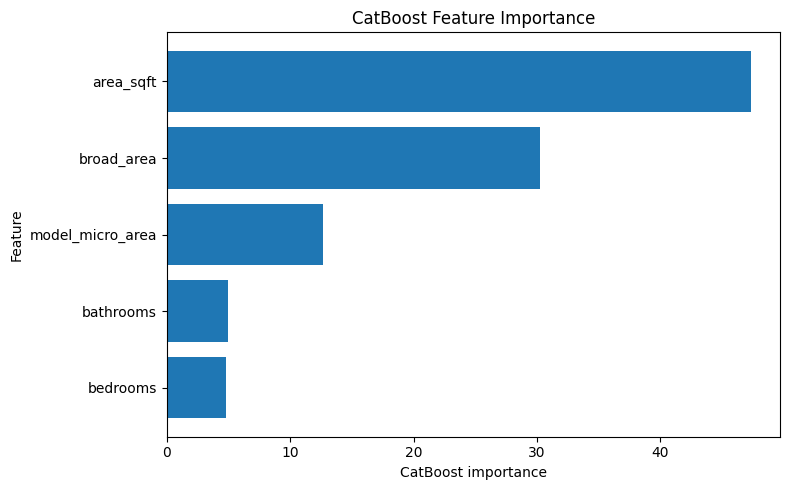

Saved: /content/drive/MyDrive/DhakaNest_ML/reports/figures/catboost/feature_importance.png


In [50]:
plot_feature_importance_df = (
    feature_importance_df
    .sort_values(
        "importance",
        ascending=True,
    )
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_feature_importance_df[
        "feature"
    ],
    plot_feature_importance_df[
        "importance"
    ],
)

plt.xlabel("CatBoost importance")
plt.ylabel("Feature")

plt.title(
    "CatBoost Feature Importance"
)

plt.tight_layout()

FEATURE_IMPORTANCE_FIGURE_PATH = (
    CATBOOST_FIGURES_DIR
    / "feature_importance.png"
)

plt.savefig(
    FEATURE_IMPORTANCE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FEATURE_IMPORTANCE_FIGURE_PATH,
)

## Unseen Micro-Area Challenge

The selected CatBoost configuration is retrained on the challenge-training
subset. Complete micro-areas excluded from that subset are then evaluated.

In [51]:
effective_iterations = int(
    chosen_model.tree_count_
)

print(
    "Iterations for challenge models:",
    effective_iterations,
)

Iterations for challenge models: 808


In [52]:
def train_and_evaluate_challenge_model(
    training_dataframe,
    challenge_dataframe,
    feature_columns,
    categorical_features,
    target_strategy,
):
    X_challenge_train = (
        prepare_catboost_features(
            training_dataframe,
            feature_columns,
            categorical_features,
        )
    )

    X_challenge_evaluation = (
        prepare_catboost_features(
            challenge_dataframe,
            feature_columns,
            categorical_features,
        )
    )

    y_challenge_train = (
        training_dataframe[
            TARGET_COLUMN
        ].astype(float)
    )

    y_challenge_evaluation = (
        challenge_dataframe[
            TARGET_COLUMN
        ].astype(float)
    )

    if target_strategy == "log1p":
        fitted_target = np.log1p(
            y_challenge_train.to_numpy()
        )
    else:
        fitted_target = (
            y_challenge_train.to_numpy()
        )

    categorical_indices = [
        feature_columns.index(column)
        for column in categorical_features
    ]

    model_arguments = {
        "loss_function": "RMSE",
        "eval_metric": "MAE",
        "iterations": (
            effective_iterations
        ),
        "bootstrap_type": "Bayesian",
        "random_seed": RANDOM_STATE,
        "thread_count": -1,
        "verbose": False,
        "allow_writing_files": False,
        **best_search_parameters,
    }

    if categorical_indices:
        model_arguments[
            "cat_features"
        ] = categorical_indices

    challenge_model = (
        CatBoostRegressor(
            **model_arguments
        )
    )

    training_start = perf_counter()

    challenge_model.fit(
        X_challenge_train,
        fitted_target,
        verbose=False,
    )

    training_seconds = (
        perf_counter()
        - training_start
    )

    metrics, predictions = (
        evaluate_catboost_model(
            challenge_model,
            X_challenge_evaluation,
            y_challenge_evaluation,
            target_strategy,
        )
    )

    metrics[
        "training_time_seconds"
    ] = float(training_seconds)

    return {
        "model": challenge_model,
        "metrics": metrics,
        "predictions": predictions,
    }

In [53]:
unseen_primary_result = (
    train_and_evaluate_challenge_model(
        training_dataframe=(
            unseen_train_df
        ),
        challenge_dataframe=(
            unseen_challenge_df
        ),
        feature_columns=(
            FEATURE_COLUMNS
        ),
        categorical_features=(
            CATEGORICAL_FEATURES
        ),
        target_strategy=(
            chosen_target_strategy
        ),
    )
)

unseen_primary_metrics = (
    unseen_primary_result["metrics"]
)

print(
    "Primary pipeline unseen-location metrics:"
)

display(
    pd.DataFrame(
        [unseen_primary_metrics]
    )
)

Primary pipeline unseen-location metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record,training_time_seconds
0,2781.091393,4037.369017,0.650848,14.759909,1966.186346,6240.014885,0.014892,0.013308,7.193001


In [54]:
BROAD_FALLBACK_FEATURES = [
    "broad_area",
    "area_sqft",
    "bedrooms",
    "bathrooms",
]

broad_fallback_result = (
    train_and_evaluate_challenge_model(
        training_dataframe=(
            unseen_train_df
        ),
        challenge_dataframe=(
            unseen_challenge_df
        ),
        feature_columns=(
            BROAD_FALLBACK_FEATURES
        ),
        categorical_features=[
            "broad_area"
        ],
        target_strategy=(
            chosen_target_strategy
        ),
    )
)

broad_fallback_metrics = (
    broad_fallback_result["metrics"]
)

print(
    "Broad-area fallback metrics:"
)

display(
    pd.DataFrame(
        [broad_fallback_metrics]
    )
)

Broad-area fallback metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record,training_time_seconds
0,2835.599302,4104.14411,0.639203,15.353269,2030.030917,6342.164236,0.00455,0.004066,3.92242


In [55]:
DHAKA_WIDE_FEATURES = [
    "area_sqft",
    "bedrooms",
    "bathrooms",
]

dhaka_wide_result = (
    train_and_evaluate_challenge_model(
        training_dataframe=(
            unseen_train_df
        ),
        challenge_dataframe=(
            unseen_challenge_df
        ),
        feature_columns=(
            DHAKA_WIDE_FEATURES
        ),
        categorical_features=[],
        target_strategy=(
            chosen_target_strategy
        ),
    )
)

dhaka_wide_metrics = (
    dhaka_wide_result["metrics"]
)

print(
    "Dhaka-wide fallback metrics:"
)

display(
    pd.DataFrame(
        [dhaka_wide_metrics]
    )
)

Dhaka-wide fallback metrics:


,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record,training_time_seconds
0,3065.862929,4671.072708,0.53264,17.087014,2212.487848,6708.364036,0.002856,0.002553,1.607992


In [56]:
unseen_comparison_df = (
    pd.DataFrame([
        {
            "strategy": (
                "primary_pipeline_"
                "unknown_micro_area"
            ),
            **unseen_primary_metrics,
        },
        {
            "strategy": (
                "broad_area_fallback"
            ),
            **broad_fallback_metrics,
        },
        {
            "strategy": (
                "dhaka_wide_fallback"
            ),
            **dhaka_wide_metrics,
        },
    ])
    .sort_values(
        "mae_bdt",
        ascending=True,
    )
)

UNSEEN_COMPARISON_PATH = (
    METRICS_DIR
    / "catboost_unseen_location_comparison.csv"
)

unseen_comparison_df.to_csv(
    UNSEEN_COMPARISON_PATH,
    index=False,
)

display(unseen_comparison_df)

print(
    "Saved:",
    UNSEEN_COMPARISON_PATH,
)

,strategy,mae_bdt,rmse_bdt,r2,mape_percent,median_absolute_error_bdt,p90_absolute_error_bdt,prediction_time_seconds,milliseconds_per_record,training_time_seconds
0,primary_pipeline_unknown_micro_area,2781.091393,4037.369017,0.650848,14.759909,1966.186346,6240.014885,0.014892,0.013308,7.193001
1,broad_area_fallback,2835.599302,4104.144110,0.639203,15.353269,2030.030917,6342.164236,0.004550,0.004066,3.922420
2,dhaka_wide_fallback,3065.862929,4671.072708,0.532640,17.087014,2212.487848,6708.364036,0.002856,0.002553,1.607992


Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/catboost_unseen_location_comparison.csv


In [57]:
best_parameters_export = {
    "search_best_parameters": (
        search.best_params_
    ),
    "best_core_parameters": (
        best_search_parameters
    ),
    "searched_iterations": (
        searched_iterations
    ),
    "final_max_iterations": (
        MAX_FINAL_ITERATIONS
    ),
    "early_stopping_rounds": (
        EARLY_STOPPING_ROUNDS
    ),
    "selected_best_iteration": int(
        chosen_model.get_best_iteration()
    ),
    "selected_tree_count": int(
        chosen_model.tree_count_
    ),
    "target_strategy": (
        chosen_target_strategy
    ),
}

BEST_PARAMETERS_PATH = (
    CATBOOST_ARTIFACT_DIR
    / "best_parameters.json"
)

with BEST_PARAMETERS_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        best_parameters_export,
        file,
        indent=2,
    )

print(
    "Saved:",
    BEST_PARAMETERS_PATH,
)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/catboost/best_parameters.json


In [58]:
feature_schema = {
    "model_name": (
        "CatBoost Regressor"
    ),
    "candidate_version": "1.0.0",
    "feature_order": FEATURE_COLUMNS,
    "categorical_features": (
        CATEGORICAL_FEATURES
    ),
    "categorical_indices": (
        CATEGORICAL_INDICES
    ),
    "numerical_features": (
        NUMERICAL_FEATURES
    ),
    "target_column": TARGET_COLUMN,
    "target_strategy": (
        chosen_target_strategy
    ),
    "currency": "BDT",
    "external_preprocessor_required": (
        False
    ),
    "input_rules": {
        "broad_area": (
            "normalized string"
        ),
        "model_micro_area": (
            "supported normalized "
            "micro-area or "
            "OTHER_<BROAD_AREA>"
        ),
        "area_sqft": (
            "positive numeric value"
        ),
        "bedrooms": (
            "positive numeric value"
        ),
        "bathrooms": (
            "positive numeric value"
        ),
    },
}

FEATURE_SCHEMA_PATH = (
    CATBOOST_ARTIFACT_DIR
    / "feature_schema.json"
)

with FEATURE_SCHEMA_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        feature_schema,
        file,
        indent=2,
    )

print(
    "Saved:",
    FEATURE_SCHEMA_PATH,
)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/catboost/feature_schema.json


In [59]:
MODEL_CBM_PATH = (
    CATBOOST_ARTIFACT_DIR
    / "catboost_model.cbm"
)

chosen_model.save_model(
    str(MODEL_CBM_PATH),
    format="cbm",
)

print("Saved:", MODEL_CBM_PATH)

print(
    "Model size in MB:",
    round(
        MODEL_CBM_PATH.stat().st_size
        / (1024 ** 2),
        3,
    ),
)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/catboost/catboost_model.cbm
Model size in MB: 2.061


In [60]:
sample_input = {
    "broad_area": str(
        validation_df.iloc[0][
            "broad_area"
        ]
    ),
    "model_micro_area": str(
        validation_df.iloc[0][
            "model_micro_area"
        ]
    ),
    "area_sqft": float(
        validation_df.iloc[0][
            "area_sqft"
        ]
    ),
    "bedrooms": float(
        validation_df.iloc[0][
            "bedrooms"
        ]
    ),
    "bathrooms": float(
        validation_df.iloc[0][
            "bathrooms"
        ]
    ),
}

SAMPLE_INPUT_PATH = (
    CATBOOST_ARTIFACT_DIR
    / "sample_input.json"
)

with SAMPLE_INPUT_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        sample_input,
        file,
        indent=2,
    )

print(
    json.dumps(
        sample_input,
        indent=2,
    )
)

print("Saved:", SAMPLE_INPUT_PATH)

{
  "broad_area": "Gulshan",
  "model_micro_area": "Gulshan 1",
  "area_sqft": 2200.0,
  "bedrooms": 3.0,
  "bathrooms": 4.0
}
Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/catboost/sample_input.json


In [61]:
catboost_metrics = {
    "model_name": "CatBoost",
    "candidate_version": "1.0.0",
    "target_strategy": (
        chosen_target_strategy
    ),
    "dummy_baseline": {
        "train": dummy_train_metrics,
        "validation": (
            dummy_validation_metrics
        ),
        "training_time_seconds": (
            dummy_training_time
        ),
    },
    "initial_catboost": {
        "train": (
            initial_train_metrics
        ),
        "validation": (
            initial_validation_metrics
        ),
        "training_time_seconds": (
            initial_training_time
        ),
    },
    "tuned_raw_target": {
        "train": raw_train_metrics,
        "validation": (
            raw_validation_metrics
        ),
        "training_time_seconds": (
            raw_training_time
        ),
        "best_iteration": int(
            raw_catboost_model
            .get_best_iteration()
        ),
        "tree_count": int(
            raw_catboost_model.tree_count_
        ),
    },
    "tuned_log_target": {
        "train": log_train_metrics,
        "validation": (
            log_validation_metrics
        ),
        "training_time_seconds": (
            log_training_time
        ),
        "best_iteration": int(
            log_catboost_model
            .get_best_iteration()
        ),
        "tree_count": int(
            log_catboost_model.tree_count_
        ),
    },
    "chosen_candidate": {
        "train": chosen_train_metrics,
        "validation": (
            chosen_validation_metrics
        ),
        "best_iteration": int(
            chosen_model
            .get_best_iteration()
        ),
        "tree_count": int(
            chosen_model.tree_count_
        ),
    },
    "unseen_location_challenge": {
        "primary_pipeline": (
            unseen_primary_metrics
        ),
        "broad_area_fallback": (
            broad_fallback_metrics
        ),
        "dhaka_wide_fallback": (
            dhaka_wide_metrics
        ),
    },
    "test_evaluation": None,
    "test_status": (
        "Untouched until final "
        "algorithm selection"
    ),
}

METRICS_JSON_PATH = (
    CATBOOST_ARTIFACT_DIR
    / "metrics.json"
)

REPORT_METRICS_PATH = (
    METRICS_DIR
    / "catboost_metrics.json"
)

for output_path in [
    METRICS_JSON_PATH,
    REPORT_METRICS_PATH,
]:
    with output_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            catboost_metrics,
            file,
            indent=2,
        )

    print("Saved:", output_path)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/catboost/metrics.json
Saved: /content/drive/MyDrive/DhakaNest_ML/reports/metrics/catboost_metrics.json


In [62]:
reloaded_model = CatBoostRegressor()

reloaded_model.load_model(
    str(MODEL_CBM_PATH),
    format="cbm",
)

sample_input_df = pd.DataFrame(
    [sample_input],
    columns=FEATURE_COLUMNS,
)

sample_input_df = (
    prepare_catboost_features(
        sample_input_df,
        FEATURE_COLUMNS,
        CATEGORICAL_FEATURES,
    )
)

prediction_before_reload = (
    convert_predictions_to_bdt(
        chosen_model.predict(
            sample_input_df
        ),
        chosen_target_strategy,
    )[0]
)

prediction_after_reload = (
    convert_predictions_to_bdt(
        reloaded_model.predict(
            sample_input_df
        ),
        chosen_target_strategy,
    )[0]
)

print(
    "Prediction before reload:",
    prediction_before_reload,
)

print(
    "Prediction after reload:",
    prediction_after_reload,
)

assert np.isclose(
    prediction_before_reload,
    prediction_after_reload,
    rtol=0,
    atol=1e-6,
), (
    "Prediction changed after "
    "artifact reload."
)

print(
    "Artifact reload verification passed."
)

Prediction before reload: 81035.33823450687
Prediction after reload: 81035.33823450687
Artifact reload verification passed.


In [63]:
reload_test_X = X_validation.head(
    20
)

original_predictions = (
    convert_predictions_to_bdt(
        chosen_model.predict(
            reload_test_X
        ),
        chosen_target_strategy,
    )
)

reloaded_predictions = (
    convert_predictions_to_bdt(
        reloaded_model.predict(
            reload_test_X
        ),
        chosen_target_strategy,
    )
)

assert np.allclose(
    original_predictions,
    reloaded_predictions,
    rtol=0,
    atol=1e-6,
), (
    "Reloaded model predictions "
    "do not match."
)

print(
    "All 20 reload-test predictions matched."
)

All 20 reload-test predictions matched.


In [64]:
def calculate_sha256(
    file_path,
):
    sha256 = hashlib.sha256()

    with Path(file_path).open(
        "rb"
    ) as file:
        for block in iter(
            lambda: file.read(
                1024 * 1024
            ),
            b"",
        ):
            sha256.update(block)

    return sha256.hexdigest()

In [65]:
model_manifest = {
    "project_name": "DhakaNest",
    "model_name": "CatBoost",
    "candidate_version": "1.0.0",
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "catboost_version": (
        catboost.__version__
    ),
    "target_strategy": (
        chosen_target_strategy
    ),
    "feature_columns": (
        FEATURE_COLUMNS
    ),
    "categorical_features": (
        CATEGORICAL_FEATURES
    ),
    "target_column": TARGET_COLUMN,
    "training_rows": int(
        len(train_df)
    ),
    "validation_rows": int(
        len(validation_df)
    ),
    "test_rows_used": 0,
    "random_state": RANDOM_STATE,
    "cross_validation": {
        "method": "GroupKFold",
        "folds": 5,
        "search_method": (
            "RandomizedSearchCV"
        ),
        "search_iterations": 15,
        "selection_metric": (
            "negative mean absolute error"
        ),
    },
    "early_stopping": {
        "maximum_iterations": (
            MAX_FINAL_ITERATIONS
        ),
        "early_stopping_rounds": (
            EARLY_STOPPING_ROUNDS
        ),
        "selected_best_iteration": int(
            chosen_model
            .get_best_iteration()
        ),
        "selected_tree_count": int(
            chosen_model.tree_count_
        ),
    },
    "best_parameters": (
        best_parameters_export
    ),
    "validation_metrics": (
        chosen_validation_metrics
    ),
    "artifact_files": {
        "native_model": (
            MODEL_CBM_PATH.name
        ),
        "metrics": (
            METRICS_JSON_PATH.name
        ),
        "feature_schema": (
            FEATURE_SCHEMA_PATH.name
        ),
        "sample_input": (
            SAMPLE_INPUT_PATH.name
        ),
    },
    "checksums": {
        "native_model_sha256": (
            calculate_sha256(
                MODEL_CBM_PATH
            )
        ),
    },
    "external_preprocessor_required": (
        False
    ),
    "artifact_reload_verified": True,
    "test_status": (
        "Official test set remains untouched."
    ),
}

MODEL_MANIFEST_PATH = (
    CATBOOST_ARTIFACT_DIR
    / "model_manifest.json"
)

with MODEL_MANIFEST_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_manifest,
        file,
        indent=2,
    )

print(
    "Saved:",
    MODEL_MANIFEST_PATH,
)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/catboost/model_manifest.json


In [66]:
model_card = f"""# DhakaNest CatBoost Candidate

## Model

- Algorithm: CatBoost Regressor
- Candidate version: 1.0.0
- CatBoost version: {catboost.__version__}
- Target strategy: {chosen_target_strategy}
- Random state: {RANDOM_STATE}
- Best iteration: {chosen_model.get_best_iteration()}
- Saved tree count: {chosen_model.tree_count_}

## Inputs

- Broad area
- Model micro-area
- Area in square feet
- Number of bedrooms
- Number of bathrooms

## Categorical Processing

CatBoost processes the broad-area and model-micro-area variables directly as
categorical features. No external one-hot encoder is required.

## Target

Monthly base rent in BDT.

## Dataset

- Training rows: {len(train_df):,}
- Validation rows: {len(validation_df):,}
- Test rows used during candidate development: 0

## Validation Performance

- MAE: BDT {chosen_validation_metrics["mae_bdt"]:,.2f}
- RMSE: BDT {chosen_validation_metrics["rmse_bdt"]:,.2f}
- R²: {chosen_validation_metrics["r2"]:.4f}
- MAPE: {chosen_validation_metrics["mape_percent"]:.2f}%
- Median absolute error:
  BDT {chosen_validation_metrics["median_absolute_error_bdt"]:,.2f}
- P90 absolute error:
  BDT {chosen_validation_metrics["p90_absolute_error_bdt"]:,.2f}

## Development Method

Hyperparameters were selected using RandomizedSearchCV with five-fold
GroupKFold cross-validation. The final raw-target and log-target candidates
were trained using validation-based early stopping.

## Unseen Locations

The model was separately evaluated using complete micro-areas excluded from
a challenge-training subset. Broad-area and Dhaka-wide fallback strategies
were also evaluated.

## Export

The fitted model is stored in native CatBoost CBM format. The selected target
transformation and required feature order are stored in the feature schema
and model manifest.

## Limitations

- The source data does not include listing IDs, dates, exact coordinates,
  furnishing, facilities, service charges, or landlord identities.
- Location prediction quality depends on source-location normalization.
- Predictions represent historical base-rent patterns in the dataset.
- The official test dataset has not yet been evaluated.
- This candidate must be compared with Random Forest and XGBoost before final
  production selection.

## Deployment Status

Candidate artifacts were exported and successfully reloaded. The model is not
yet approved as the final production algorithm.
"""

MODEL_CARD_PATH = (
    CATBOOST_ARTIFACT_DIR
    / "model_card.md"
)

MODEL_CARD_PATH.write_text(
    model_card,
    encoding="utf-8",
)

print("Saved:", MODEL_CARD_PATH)

Saved: /content/drive/MyDrive/DhakaNest_ML/artifacts/candidates/catboost/model_card.md


In [67]:
required_catboost_outputs = [
    MODEL_CBM_PATH,
    METRICS_JSON_PATH,
    BEST_PARAMETERS_PATH,
    FEATURE_SCHEMA_PATH,
    ENVIRONMENT_PATH,
    SAMPLE_INPUT_PATH,
    MODEL_MANIFEST_PATH,
    MODEL_CARD_PATH,
    CATBOOST_COMPARISON_PATH,
    CV_RESULTS_PATH,
    VALIDATION_PREDICTIONS_PATH,
    FEATURE_IMPORTANCE_PATH,
    UNSEEN_COMPARISON_PATH,
    LARGEST_ERRORS_PATH,
    ACTUAL_PREDICTED_FIGURE_PATH,
    RESIDUAL_FIGURE_PATH,
    FEATURE_IMPORTANCE_FIGURE_PATH,
    RAW_LEARNING_CURVE_PATH,
    LOG_LEARNING_CURVE_PATH,
]

missing_outputs = [
    str(path)
    for path in required_catboost_outputs
    if not path.exists()
]

empty_outputs = [
    str(path)
    for path in required_catboost_outputs
    if (
        path.exists()
        and path.is_file()
        and path.stat().st_size == 0
    )
]

if missing_outputs:
    raise FileNotFoundError(
        "Missing CatBoost outputs:\n"
        + "\n".join(
            missing_outputs
        )
    )

if empty_outputs:
    raise ValueError(
        "Empty CatBoost outputs:\n"
        + "\n".join(
            empty_outputs
        )
    )

assert MODEL_CBM_PATH.stat().st_size > 0

assert (
    chosen_validation_metrics[
        "mae_bdt"
    ] > 0
)

assert (
    chosen_validation_metrics[
        "rmse_bdt"
    ] > 0
)

print("=" * 70)

print(
    "CATBOOST CANDIDATE "
    "COMPLETED SUCCESSFULLY"
)

print("=" * 70)

print(
    "Selected target strategy:",
    chosen_target_strategy,
)

print(
    "Best iteration:",
    chosen_model.get_best_iteration(),
)

print(
    "Saved tree count:",
    chosen_model.tree_count_,
)

print(
    "Validation MAE:",
    round(
        chosen_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
)

print(
    "Validation RMSE:",
    round(
        chosen_validation_metrics[
            "rmse_bdt"
        ],
        2,
    ),
)

print(
    "Validation R²:",
    round(
        chosen_validation_metrics[
            "r2"
        ],
        4,
    ),
)

print(
    "Validation MAPE:",
    round(
        chosen_validation_metrics[
            "mape_percent"
        ],
        2,
    ),
)

print("Official test rows evaluated: 0")
print("Artifact reload verified: Yes")
print("All required files exist.")

CATBOOST CANDIDATE COMPLETED SUCCESSFULLY
Selected target strategy: log1p
Best iteration: 807
Saved tree count: 808
Validation MAE: 3635.5
Validation RMSE: 9238.22
Validation R²: 0.827
Validation MAPE: 12.73
Official test rows evaluated: 0
Artifact reload verified: Yes
All required files exist.


In [68]:
summary_for_review = {
    "model": "CatBoost",
    "catboost_version": (
        catboost.__version__
    ),
    "target_strategy": (
        chosen_target_strategy
    ),
    "training_rows": int(
        len(train_df)
    ),
    "validation_rows": int(
        len(validation_df)
    ),
    "dummy_validation_mae_bdt": round(
        dummy_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "initial_catboost_validation_mae_bdt": round(
        initial_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "tuned_raw_validation_mae_bdt": round(
        raw_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "tuned_log_validation_mae_bdt": round(
        log_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "selected_validation_mae_bdt": round(
        chosen_validation_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "selected_validation_rmse_bdt": round(
        chosen_validation_metrics[
            "rmse_bdt"
        ],
        2,
    ),
    "selected_validation_r2": round(
        chosen_validation_metrics[
            "r2"
        ],
        4,
    ),
    "selected_validation_mape_percent": round(
        chosen_validation_metrics[
            "mape_percent"
        ],
        2,
    ),
    "selected_validation_median_absolute_error_bdt": round(
        chosen_validation_metrics[
            "median_absolute_error_bdt"
        ],
        2,
    ),
    "selected_validation_p90_absolute_error_bdt": round(
        chosen_validation_metrics[
            "p90_absolute_error_bdt"
        ],
        2,
    ),
    "train_validation_mae_gap_bdt": round(
        chosen_validation_metrics[
            "mae_bdt"
        ]
        - chosen_train_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "selected_best_iteration": int(
        chosen_model.get_best_iteration()
    ),
    "selected_tree_count": int(
        chosen_model.tree_count_
    ),
    "unseen_primary_mae_bdt": round(
        unseen_primary_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "broad_area_fallback_mae_bdt": round(
        broad_fallback_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "dhaka_wide_fallback_mae_bdt": round(
        dhaka_wide_metrics[
            "mae_bdt"
        ],
        2,
    ),
    "best_parameters": (
        search.best_params_
    ),
    "artifact_reload_verified": True,
    "official_test_evaluated": False,
}

print(
    json.dumps(
        summary_for_review,
        indent=2,
    )
)

{
  "model": "CatBoost",
  "catboost_version": "1.2.10",
  "target_strategy": "log1p",
  "training_rows": 10668,
  "validation_rows": 2289,
  "dummy_validation_mae_bdt": 9648.19,
  "initial_catboost_validation_mae_bdt": 3995.61,
  "tuned_raw_validation_mae_bdt": 3931.4,
  "tuned_log_validation_mae_bdt": 3635.5,
  "selected_validation_mae_bdt": 3635.5,
  "selected_validation_rmse_bdt": 9238.22,
  "selected_validation_r2": 0.827,
  "selected_validation_mape_percent": 12.73,
  "selected_validation_median_absolute_error_bdt": 1621.41,
  "selected_validation_p90_absolute_error_bdt": 6519.85,
  "train_validation_mae_gap_bdt": 579.61,
  "selected_best_iteration": 807,
  "selected_tree_count": 808,
  "unseen_primary_mae_bdt": 2781.09,
  "broad_area_fallback_mae_bdt": 2835.6,
  "dhaka_wide_fallback_mae_bdt": 3065.86,
  "best_parameters": {
    "random_strength": 2.0,
    "learning_rate": 0.06,
    "l2_leaf_reg": 1.0,
    "iterations": 1300,
    "depth": 6,
    "border_count": 254,
    "bagging_

In [69]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/content/drive/MyDrive/DhakaNest_ML")

files_to_check = [
    # -------------------------------------------------
    # Shared frozen datasets
    # -------------------------------------------------
    PROJECT_ROOT / "data/splits/train.csv",
    PROJECT_ROOT / "data/splits/validation.csv",
    PROJECT_ROOT / "data/splits/test.csv",
    PROJECT_ROOT / "data/splits/unseen_micro_area_train.csv",
    PROJECT_ROOT / "data/splits/unseen_micro_area_challenge.csv",

    # -------------------------------------------------
    # CatBoost model artifacts
    # -------------------------------------------------
    PROJECT_ROOT / "artifacts/candidates/catboost/catboost_model.cbm",
    PROJECT_ROOT / "artifacts/candidates/catboost/metrics.json",
    PROJECT_ROOT / "artifacts/candidates/catboost/best_parameters.json",
    PROJECT_ROOT / "artifacts/candidates/catboost/feature_schema.json",
    PROJECT_ROOT / "artifacts/candidates/catboost/training_environment.json",
    PROJECT_ROOT / "artifacts/candidates/catboost/sample_input.json",
    PROJECT_ROOT / "artifacts/candidates/catboost/model_manifest.json",
    PROJECT_ROOT / "artifacts/candidates/catboost/model_card.md",

    # -------------------------------------------------
    # CatBoost metrics and evaluation outputs
    # -------------------------------------------------
    PROJECT_ROOT / "reports/metrics/catboost_metrics.json",
    PROJECT_ROOT / "reports/metrics/catboost_validation_comparison.csv",
    PROJECT_ROOT / "reports/metrics/catboost_cv_results.csv",
    PROJECT_ROOT / "reports/metrics/catboost_validation_predictions.csv",
    PROJECT_ROOT / "reports/metrics/catboost_largest_validation_errors.csv",
    PROJECT_ROOT / "reports/metrics/catboost_feature_importance.csv",
    PROJECT_ROOT / "reports/metrics/catboost_unseen_location_comparison.csv",

    # -------------------------------------------------
    # CatBoost segment evaluation outputs
    # -------------------------------------------------
    PROJECT_ROOT / "reports/segment_evaluation/catboost_by_broad_area.csv",
    PROJECT_ROOT / "reports/segment_evaluation/catboost_by_model_micro_area.csv",
    PROJECT_ROOT / "reports/segment_evaluation/catboost_by_micro_area_support.csv",
    PROJECT_ROOT / "reports/segment_evaluation/catboost_by_bedroom_count.csv",
    PROJECT_ROOT / "reports/segment_evaluation/catboost_by_bathroom_count.csv",
    PROJECT_ROOT / "reports/segment_evaluation/catboost_by_rent_range.csv",
    PROJECT_ROOT / "reports/segment_evaluation/catboost_by_area_range.csv",

    # -------------------------------------------------
    # CatBoost figures
    # -------------------------------------------------
    PROJECT_ROOT / "reports/figures/catboost/actual_vs_predicted.png",
    PROJECT_ROOT / "reports/figures/catboost/validation_residual_distribution.png",
    PROJECT_ROOT / "reports/figures/catboost/feature_importance.png",
    PROJECT_ROOT / "reports/figures/catboost/raw_target_learning_curve.png",
    PROJECT_ROOT / "reports/figures/catboost/log_target_learning_curve.png",

    # -------------------------------------------------
    # Saved notebook
    # -------------------------------------------------
    PROJECT_ROOT / "notebooks/03_DhakaNest_CatBoost.ipynb",
]

verification_rows = []
missing_files = []
empty_files = []

for path in files_to_check:
    exists = path.exists()
    size_bytes = path.stat().st_size if exists and path.is_file() else 0
    is_empty = exists and path.is_file() and size_bytes == 0

    verification_rows.append({
        "file": str(path.relative_to(PROJECT_ROOT)),
        "exists": exists,
        "size_kb": round(size_bytes / 1024, 2),
        "status": (
            "OK"
            if exists and not is_empty
            else "EMPTY"
            if is_empty
            else "MISSING"
        ),
    })

    if not exists:
        missing_files.append(str(path))
    elif is_empty:
        empty_files.append(str(path))

verification_df = pd.DataFrame(verification_rows)

display(verification_df)

print("=" * 70)
print("CATBOOST GOOGLE DRIVE VERIFICATION")
print("=" * 70)
print("Files checked:", len(files_to_check))
print("Missing files:", len(missing_files))
print("Empty files:", len(empty_files))

if missing_files:
    print("\nMissing files:")

    for path in missing_files:
        print("-", path)

if empty_files:
    print("\nEmpty files:")

    for path in empty_files:
        print("-", path)

if not missing_files and not empty_files:
    print(
        "\nAll required CatBoost files are safely stored "
        "in Google Drive."
    )
else:
    print(
        "\nVerification failed. Review the missing or empty "
        "files before moving to Notebook 04."
    )

,file,exists,size_kb,status
0,data/splits/train.csv,True,1084.06,OK
1,data/splits/validation.csv,True,232.65,OK
2,data/splits/test.csv,True,233.32,OK
3,data/splits/unseen_micro_area_train.csv,True,972.33,OK
4,data/splits/unseen_micro_area_challenge.csv,True,111.88,OK
5,artifacts/candidates/catboost/catboost_model.cbm,True,2110.96,OK
6,artifacts/candidates/catboost/metrics.json,True,5.64,OK
7,artifacts/candidates/catboost/best_parameters....,True,0.57,OK
8,artifacts/candidates/catboost/feature_schema.json,True,0.77,OK
9,artifacts/candidates/catboost/training_environ...,True,0.23,OK


CATBOOST GOOGLE DRIVE VERIFICATION
Files checked: 33
Missing files: 0
Empty files: 0

All required CatBoost files are safely stored in Google Drive.
